<a href="https://colab.research.google.com/github/FolatheDuckofDuckingburg/FolatheDuckofDuckingburg/blob/main/NFOTheory_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import torch
import torch.nn as nn
import numpy as np
from scipy import signal

SAMPLING_RATE = 256
WINDOW_DURATION = 2
WINDOW_SIZE = SAMPLING_RATE * WINDOW_DURATION
BLINK_THRESHOLD = 150.0

class AttentionClassifierNet(nn.Module):
    def __init__(self):
        super(AttentionClassifierNet, self).__init__()
        # Updated input layer to accept 6 features (log_tbr, log_theta, log_beta, log_delta, log_alpha, log_gamma)
        self.layer_1 = nn.Linear(6, 8)
        self.layer_2 = nn.Linear(8, 4)
        self.output_layer = nn.Linear(4, 1)
        self.activation = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.activation(self.layer_1(x))
        x = self.activation(self.layer_2(x))
        x = self.sigmoid(self.output_layer(x))
        return x

def process_eeg_window(raw_signal_data):
    cleaned_signal = np.where(np.abs(raw_signal_data) > BLINK_THRESHOLD, 0.0, raw_signal_data)
    frequencies, power_density = signal.welch(cleaned_signal, fs=SAMPLING_RATE, nperseg=WINDOW_SIZE)

    # Define frequency bands
    delta_indices = np.where((frequencies >= 0.5) & (frequencies <= 4))
    theta_indices = np.where((frequencies >= 4) & (frequencies <= 7))
    alpha_indices = np.where((frequencies >= 8) & (frequencies <= 12))
    beta_indices = np.where((frequencies >= 13) & (frequencies <= 30))
    gamma_indices = np.where((frequencies >= 30) & (frequencies <= 70))

    # Calculate power for each band
    delta_power = np.sum(power_density[delta_indices])
    theta_power = np.sum(power_density[theta_indices])
    alpha_power = np.sum(power_density[alpha_indices])
    beta_power = np.sum(power_density[beta_indices])
    gamma_power = np.sum(power_density[gamma_indices])

    tbr_ratio = theta_power / (beta_power + 1e-6)

    # Log-normalize all powers and ratio
    log_tbr = np.log1p(tbr_ratio)
    log_theta = np.log1p(theta_power)
    log_beta = np.log1p(beta_power)
    log_delta = np.log1p(delta_power)
    log_alpha = np.log1p(alpha_power)
    log_gamma = np.log1p(gamma_power)

    # Return all log-normalized features
    return torch.tensor([log_tbr, log_theta, log_beta, log_delta, log_alpha, log_gamma], dtype=torch.float32)

def generate_synthetic_eeg_stream(state="focused"):
    t = np.linspace(0, WINDOW_DURATION, WINDOW_SIZE)
    noise = np.random.normal(0, 15, WINDOW_SIZE)

    if state == "drift":
        theta_wave = 45 * np.sin(2 * np.pi * 5.5 * t) + np.random.normal(0, 5, WINDOW_SIZE) # Add more variability
        beta_wave = 5 * np.sin(2 * np.pi * 20 * t) + np.random.normal(0, 5, WINDOW_SIZE)
        alpha_wave = 15 * np.sin(2 * np.pi * 10 * t) # Add alpha wave for drift state
        delta_wave = 20 * np.sin(2 * np.pi * 2 * t) # Add delta wave for drift state
        gamma_wave = 10 * np.sin(2 * np.pi * 40 * t) # Add gamma wave for drift state
    else: # Focused state
        theta_wave = 10 * np.sin(2 * np.pi * 5.5 * t) + np.random.normal(0, 2, WINDOW_SIZE)
        beta_wave = 35 * np.sin(2 * np.pi * 20 * t) + np.random.normal(0, 2, WINDOW_SIZE) # Less variability for focused
        alpha_wave = 25 * np.sin(2 * np.pi * 10 * t) # Different alpha wave for focused state
        delta_wave = 5 * np.sin(2 * np.pi * 2 * t) # Different delta wave for focused state
        gamma_wave = 5 * np.sin(2 * np.pi * 40 * t) # Different gamma wave for focused state

    simulated_signal = theta_wave + beta_wave + alpha_wave + delta_wave + gamma_wave + noise
    if np.random.rand() > 0.8: # Keep blink simulation
        simulated_signal[120:125] = 220.0

    return simulated_signal

def train_network(model):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005) # Slightly reduced learning rate
    criterion = nn.BCELoss()

    X_train, y_train = [], []
    # Increased number of training samples for better learning
    for _ in range(250): # From 50 to 250 samples per state
        X_train.append(process_eeg_window(generate_synthetic_eeg_stream("focused")))
        y_train.append([0.0])
        X_train.append(process_eeg_window(generate_synthetic_eeg_stream("drift")))
        y_train.append([1.0])

    X_train = torch.stack(X_train)
    y_train = torch.tensor(y_train, dtype=torch.float32)

    model.train()
    for epoch in range(200): # Increased epochs for more training iterations
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
    model.eval()

if __name__ == "__main__":
    model = AttentionClassifierNet()
    train_network(model)

    states_to_test = ["focused", "drift"]

    print("--- NOGGIN SYNTHETIC TESTING PLATFORM ---")
    for current_state in states_to_test:
        simulated_brainwaves = generate_synthetic_eeg_stream(state=current_state)
        input_features = process_eeg_window(simulated_brainwaves)

        with torch.no_grad():
            drift_probability = model(input_features.unsqueeze(0)).item()

        print(f"\nSimulated State: {current_state.upper()}")
        print(f"Log-Normalized Features Array: {input_features.numpy()}")
        print(f"Network Drift Score: {drift_probability * 100:.2f}%")

--- NOGGIN SYNTHETIC TESTING PLATFORM ---

Simulated State: FOCUSED
Log-Normalized Features Array: [0.07780448 4.63966    7.1451426  3.7787879  6.449336   4.9336686 ]
Network Drift Score: 0.10%

Simulated State: DRIFT
Log-Normalized Features Array: [3.1560037 7.6432633 4.5410295 6.147004  5.220694  5.437675 ]
Network Drift Score: 73.79%


### Exporting the Trained Model to ONNX

To use the trained model in other environments or applications, such as an EdTech application, we can export it to the Open Neural Network Exchange (ONNX) format. ONNX provides a standardized way to represent machine learning models, allowing for interoperability between different frameworks and deployment tools.

First, we'll re-instantiate and train the model, then define a dummy input tensor that matches the expected input shape of our `AttentionClassifierNet` (batch size of 1, with 6 features). Finally, we'll use `torch.onnx.export` to save the model to an ONNX file.

In [7]:
# Re-instantiate and train the model
# (This is necessary because the model was trained within an `if __name__ == "__main__":` block and not globally accessible)
model_to_export = AttentionClassifierNet()
train_network(model_to_export)

# Set the model to evaluation mode
model_to_export.eval()

# Define a dummy input for ONNX export
# The model expects a tensor of shape (batch_size, num_features)
# Our model has 6 features, so a dummy input for a single sample is (1, 6)
dummy_input = torch.randn(1, 6)

# Define the path for the ONNX model
onnx_model_path = "attention_classifier.onnx"

# Export the model
torch.onnx.export(
    model_to_export,            # Trained model
    dummy_input,                # Dummy input to trace the model
    onnx_model_path,            # Where to save the ONNX model
    export_params=True,         # Store the trained parameter weights inside the model file
    opset_version=11,           # The ONNX operator set version to use
    do_constant_folding=True,   # Whether to execute constant folding for optimization
    input_names = ['input'],    # Input name for the ONNX model
    output_names = ['output'],  # Output name for the ONNX model
    dynamic_axes={'input' : {0 : 'batch_size'},    # Variable batch size
                  'output' : {0 : 'batch_size'}}
)

print(f"Model exported to {onnx_model_path}")

ModuleNotFoundError: No module named 'onnxscript'

### Verify ONNX Model (Optional)

You can optionally verify the exported ONNX model using the `onnx` library. This step ensures that the model is valid and can be loaded correctly.

In [9]:
try:
    import onnx
    # Load the ONNX model
    onnx_model = onnx.load(onnx_model_path)
    # Check that the model is well formed
    onnx.checker.check_model(onnx_model)
    print(f"ONNX model '{onnx_model_path}' is valid and loaded successfully.")
except ImportError:
    print("ONNX library not found. Install with `pip install onnx` to verify the model.")
except Exception as e:
    print(f"Error verifying ONNX model: {e}")

ONNX library not found. Install with `pip install onnx` to verify the model.


In [13]:
# Install necessary libraries for ONNX export and verification
!pip install onnx onnxscript

# Re-execute the ONNX export cell after installing dependencies
# Re-instantiate and train the model
model_to_export = AttentionClassifierNet()
train_network(model_to_export)

# Set the model to evaluation mode
model_to_export.eval()

# Define a dummy input for ONNX export
dummy_input = torch.randn(1, 6)

# Define the path for the ONNX model
onnx_model_path = "attention_classifier.onnx"

# Export the model
torch.onnx.export(
    model_to_export,            # Trained model
    dummy_input,                # Dummy input to trace the model
    onnx_model_path,            # Where to save the ONNX model
    export_params=True,         # Store the trained parameter weights inside the model file
    opset_version=18,           # Changed opset_version to 18 to match PyTorch's default and avoid conversion errors
    do_constant_folding=True,   # Whether to execute constant folding for optimization
    input_names = ['input'],    # Input name for the ONNX model
    output_names = ['output'],  # Output name for the ONNX model
    dynamic_axes={'input' : {0 : 'batch_size'},    # Variable batch size
                  'output' : {0 : 'batch_size'}}
)

print(f"Model exported to {onnx_model_path}")

# Re-execute the ONNX model verification cell
try:
    import onnx
    onnx_model = onnx.load(onnx_model_path)
    onnx.checker.check_model(onnx_model)
    print(f"ONNX model '{onnx_model_path}' is valid and loaded successfully.")
except Exception as e:
    print(f"Error verifying ONNX model: {e}")

/tmp/ipykernel_807/4198537622.py:19: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `AttentionClassifierNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `AttentionClassifierNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Model exported to attention_classifier.onnx
ONNX model 'attention_classifier.onnx' is valid and loaded successfully.


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


# Task
The user wants to export a trained PyTorch model to ONNX format, verify it, and then proceed with a plan to refine the synthetic data generation, develop advanced feature engineering, integrate neuroscientific theory into model architecture, implement robust validation strategies, conduct comparative analysis with state-of-the-art, propose a real-world pilot study design, and finally summarize the proposed advancements. The current notebook shows a Python script that defines an `AttentionClassifierNet` neural network, functions to process EEG windows and generate synthetic EEG streams, and a `train_network` function to train the model. The model is trained and tested with synthetic 'focused' and 'drift' states. The notebook then attempts to export the trained model to ONNX, but encounters a `ModuleNotFoundError` for `onnxscript` and later a `ModuleNotFoundError` for `onnx`. The user has provided a fix for this by installing `onnx` and `onnxscript` and re-executing the export and verification steps. The ONNX export and verification are successful in the latest notebook state. The next step is to continue with the provided plan.

## Refine Synthetic Data Generation

### Subtask:
Enhance the realism and complexity of the synthetic EEG data by incorporating more advanced physiological noise models, simulating inter-subject variability, and introducing more dynamic and nuanced transitions between 'focused' and 'drift' states. This will make the model more robust and generalizable.


**Reasoning**:
I need to update the `generate_synthetic_eeg_stream` function to include more advanced physiological noise models. I will introduce muscle artifact noise and baseline wander to the simulated EEG signal.



In [17]:
import torch
import torch.nn as nn
import numpy as np
from scipy import signal

SAMPLING_RATE = 256
WINDOW_DURATION = 2
WINDOW_SIZE = SAMPLING_RATE * WINDOW_DURATION
BLINK_THRESHOLD = 150.0

class AttentionClassifierNet(nn.Module):
    def __init__(self):
        super(AttentionClassifierNet, self).__init__()
        # Updated input layer to accept 6 features (log_tbr, log_theta, log_beta, log_delta, log_alpha, log_gamma)
        self.layer_1 = nn.Linear(6, 8)
        self.layer_2 = nn.Linear(8, 4)
        self.output_layer = nn.Linear(4, 1)
        self.activation = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.activation(self.layer_1(x))
        x = self.activation(self.layer_2(x))
        x = self.sigmoid(self.output_layer(x))
        return x

def process_eeg_window(raw_signal_data):
    cleaned_signal = np.where(np.abs(raw_signal_data) > BLINK_THRESHOLD, 0.0, raw_signal_data)
    frequencies, power_density = signal.welch(cleaned_signal, fs=SAMPLING_RATE, nperseg=WINDOW_SIZE)

    # Define frequency bands
    delta_indices = np.where((frequencies >= 0.5) & (frequencies <= 4))
    theta_indices = np.where((frequencies >= 4) & (frequencies <= 7))
    alpha_indices = np.where((frequencies >= 8) & (frequencies <= 12))
    beta_indices = np.where((frequencies >= 13) & (frequencies <= 30))
    gamma_indices = np.where((frequencies >= 30) & (frequencies <= 70))

    # Calculate power for each band
    delta_power = np.sum(power_density[delta_indices])
    theta_power = np.sum(power_density[theta_indices])
    alpha_power = np.sum(power_density[alpha_indices])
    beta_power = np.sum(power_density[beta_indices])
    gamma_power = np.sum(power_density[gamma_indices])

    tbr_ratio = theta_power / (beta_power + 1e-6)

    # Log-normalize all powers and ratio
    log_tbr = np.log1p(tbr_ratio)
    log_theta = np.log1p(theta_power)
    log_beta = np.log1p(beta_power)
    log_delta = np.log1p(delta_power)
    log_alpha = np.log1p(alpha_power)
    log_gamma = np.log1p(gamma_power)

    # Return all log-normalized features
    return torch.tensor([log_tbr, log_theta, log_beta, log_delta, log_alpha, log_gamma], dtype=torch.float32)

def generate_synthetic_eeg_stream(blended_state_strength=0.0): # 0.0 for focused, 1.0 for drift
    t = np.linspace(0, WINDOW_DURATION, WINDOW_SIZE)

    # Introduce variability in base noise
    base_noise_std = np.random.uniform(10, 20) # Vary base noise amplitude
    noise = np.random.normal(0, base_noise_std, WINDOW_SIZE)

    # Add muscle artifact noise (high frequency, short bursts)
    if np.random.rand() < 0.3: # 30% chance of muscle artifact
        muscle_artifact_duration = int(SAMPLING_RATE * np.random.uniform(0.05, 0.2))
        muscle_artifact_start = np.random.randint(0, WINDOW_SIZE - muscle_artifact_duration)
        muscle_artifact_end = muscle_artifact_start + muscle_artifact_duration
        muscle_noise_amp = np.random.uniform(20, 30) # Vary muscle noise amplitude
        muscle_noise = np.random.normal(0, muscle_noise_amp, muscle_artifact_duration)
        noise[muscle_artifact_start:muscle_artifact_end] += muscle_noise

    # Add baseline wander (low frequency fluctuation)
    if np.random.rand() < 0.4: # 40% chance of baseline wander
        baseline_wander_freq = np.random.uniform(0.1, 0.5)
        baseline_wander_amplitude = np.random.uniform(5, 20)
        baseline_wander = baseline_wander_amplitude * np.sin(2 * np.pi * baseline_wander_freq * t)
        noise += baseline_wander

    # Define amplitude and noise ranges for focused and drift states
    # For the interpolate function to work deterministically for training, we'll use mean values or fixed ranges
    # Focused state ranges (min_val, max_val)
    theta_amp_focused_range = (8, 12)
    theta_noise_focused_range = (1, 3)
    beta_amp_focused_range = (30, 40)
    beta_noise_focused_range = (1, 3)
    alpha_amp_focused_range = (20, 30)
    delta_amp_focused_range = (3, 7)
    gamma_amp_focused_range = (3, 7)

    # Drift state ranges (min_val, max_val)
    theta_amp_drift_range = (40, 50)
    theta_noise_drift_range = (4, 6)
    beta_amp_drift_range = (4, 6)
    beta_noise_drift_range = (4, 6)
    alpha_amp_drift_range = (12, 18)
    delta_amp_drift_range = (18, 22)
    gamma_amp_drift_range = (8, 12)

    # Interpolate parameters based on blended_state_strength
    # The interpolate function now takes 4 values (min_focused, max_focused, min_drift, max_drift)
    # and interpolates between a random value from the focused range and a random value from the drift range.
    # This maintains inter-subject variability while enabling smooth transitions.
    def interpolate(min_focused, max_focused, min_drift, max_drift, strength):
        # Get a random value from the focused range
        focused_val = np.random.uniform(min_focused, max_focused)
        # Get a random value from the drift range
        drift_val = np.random.uniform(min_drift, max_drift)
        return (1 - strength) * focused_val + strength * drift_val

    theta_amp = interpolate(*theta_amp_focused_range, *theta_amp_drift_range, blended_state_strength)
    theta_noise_std = interpolate(*theta_noise_focused_range, *theta_noise_drift_range, blended_state_strength)
    beta_amp = interpolate(*beta_amp_focused_range, *beta_amp_drift_range, blended_state_strength)
    beta_noise_std = interpolate(*beta_noise_focused_range, *beta_noise_drift_range, blended_state_strength)
    alpha_amp = interpolate(*alpha_amp_focused_range, *alpha_amp_drift_range, blended_state_strength)
    delta_amp = interpolate(*delta_amp_focused_range, *delta_amp_drift_range, blended_state_strength)
    gamma_amp = interpolate(*gamma_amp_focused_range, *gamma_amp_drift_range, blended_state_strength)

    theta_wave = theta_amp * np.sin(2 * np.pi * 5.5 * t) + np.random.normal(0, theta_noise_std, WINDOW_SIZE)
    beta_wave = beta_amp * np.sin(2 * np.pi * 20 * t) + np.random.normal(0, beta_noise_std, WINDOW_SIZE)
    alpha_wave = alpha_amp * np.sin(2 * np.pi * 10 * t)
    delta_wave = delta_amp * np.sin(2 * np.pi * 2 * t)
    gamma_wave = gamma_amp * np.sin(2 * np.pi * 40 * t)

    simulated_signal = theta_wave + beta_wave + alpha_wave + delta_wave + gamma_wave + noise
    if np.random.rand() > 0.8: # Keep blink simulation
        simulated_signal[120:125] = 220.0

    return simulated_signal

def train_network(model):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005) # Slightly reduced learning rate
    criterion = nn.BCELoss()

    X_train, y_train = [], []
    # Increased number of training samples for better learning
    # Generate samples across the blend spectrum for more robust training
    num_samples_per_state = 250
    for _ in range(num_samples_per_state):
        # Pure focused state
        X_train.append(process_eeg_window(generate_synthetic_eeg_stream(blended_state_strength=0.0)))
        y_train.append([0.0])
        # Pure drift state
        X_train.append(process_eeg_window(generate_synthetic_eeg_stream(blended_state_strength=1.0)))
        y_train.append([1.0])
        # Intermediate blended states
        if np.random.rand() < 0.5: # 50% chance of generating a blended state
            intermediate_strength = np.random.uniform(0.1, 0.9) # Random strength between focused and drift
            X_train.append(process_eeg_window(generate_synthetic_eeg_stream(blended_state_strength=intermediate_strength)))
            y_train.append([intermediate_strength]) # Use the intermediate strength as the target label

    X_train = torch.stack(X_train)
    y_train = torch.tensor(y_train, dtype=torch.float32)

    model.train()
    for epoch in range(200): # Increased epochs for more training iterations
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
    model.eval()

if __name__ == "__main__":
    model = AttentionClassifierNet()
    train_network(model)

    states_to_test = {"focused": 0.0, "drift": 1.0, "mid_blend": 0.5} # Test an intermediate state

    print("--- NOGGIN SYNTHETIC TESTING PLATFORM ---")
    for current_state_name, blended_strength in states_to_test.items():
        simulated_brainwaves = generate_synthetic_eeg_stream(blended_state_strength=blended_strength)
        input_features = process_eeg_window(simulated_brainwaves)

        with torch.no_grad():
            drift_probability = model(input_features.unsqueeze(0)).item()

        print(f"\nSimulated State: {current_state_name.upper()}")
        print(f"Log-Normalized Features Array: {input_features.numpy()}")
        print(f"Network Drift Score: {drift_probability * 100:.2f}%")

--- NOGGIN SYNTHETIC TESTING PLATFORM ---

Simulated State: FOCUSED
Log-Normalized Features Array: [0.10268601 4.917292   7.1350403  3.834994   6.6702785  5.2872434 ]
Network Drift Score: 1.46%

Simulated State: DRIFT
Log-Normalized Features Array: [2.9151125 7.599728  4.748539  5.806211  5.5325456 5.4957466]
Network Drift Score: 98.31%

Simulated State: MID_BLEND
Log-Normalized Features Array: [0.9385073 6.69958   6.2580414 5.126195  6.2182055 5.2785993]
Network Drift Score: 38.16%


## Develop Advanced Feature Engineering

### Subtask:
Explore and implement more sophisticated EEG features beyond basic spectral bands. This could include connectivity measures (e.g., coherence, phase-locking value), event-related potentials (ERPs), or features derived from source localization techniques, to capture deeper neurophysiological insights relevant to ADHD and attention regulation.


**Reasoning**:
I need to modify the `process_eeg_window` function to calculate the new features (alpha-theta ratio, beta-gamma ratio, and standard deviation of the signal) and then update the `AttentionClassifierNet` to accept the increased number of input features. I will then integrate these into the feature array.



In [ ]:
import torch
import torch.nn as nn
import numpy as np
from scipy import signal

SAMPLING_RATE = 256
WINDOW_DURATION = 2
WINDOW_SIZE = SAMPLING_RATE * WINDOW_DURATION
BLINK_THRESHOLD = 150.0

class AttentionClassifierNet(nn.Module):
    def __init__(self):
        super(AttentionClassifierNet, self).__init__()
        # Updated input layer to accept 9 features (log_tbr, log_theta, log_beta, log_delta, log_alpha, log_gamma, alpha_theta_ratio, beta_gamma_ratio, signal_std)
        self.layer_1 = nn.Linear(9, 12) # Increased neurons for more features
        self.layer_2 = nn.Linear(12, 6) # Increased neurons
        self.output_layer = nn.Linear(6, 1)
        self.activation = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.activation(self.layer_1(x))
        x = self.activation(self.layer_2(x))
        x = self.sigmoid(self.output_layer(x))
        return x

def process_eeg_window(raw_signal_data):
    cleaned_signal = np.where(np.abs(raw_signal_data) > BLINK_THRESHOLD, 0.0, raw_signal_data)
    frequencies, power_density = signal.welch(cleaned_signal, fs=SAMPLING_RATE, nperseg=WINDOW_SIZE)

    # Define frequency bands
    delta_indices = np.where((frequencies >= 0.5) & (frequencies <= 4))
    theta_indices = np.where((frequencies >= 4) & (frequencies <= 7))
    alpha_indices = np.where((frequencies >= 8) & (frequencies <= 12))
    beta_indices = np.where((frequencies >= 13) & (frequencies <= 30))
    gamma_indices = np.where((frequencies >= 30) & (frequencies <= 70))

    # Calculate power for each band
    delta_power = np.sum(power_density[delta_indices])
    theta_power = np.sum(power_density[theta_indices])
    alpha_power = np.sum(power_density[alpha_indices])
    beta_power = np.sum(power_density[beta_indices])
    gamma_power = np.sum(power_density[gamma_indices])

    tbr_ratio = theta_power / (beta_power + 1e-6)

    # Calculate new advanced features
    alpha_theta_ratio = alpha_power / (theta_power + 1e-6)
    beta_gamma_ratio = beta_power / (gamma_power + 1e-6)
    signal_std = np.std(cleaned_signal) # Standard deviation as a measure of complexity

    # Log-normalize all powers and ratios
    log_tbr = np.log1p(tbr_ratio)
    log_theta = np.log1p(theta_power)
    log_beta = np.log1p(beta_power)
    log_delta = np.log1p(delta_power)
    log_alpha = np.log1p(alpha_power)
    log_gamma = np.log1p(gamma_power)
    log_alpha_theta_ratio = np.log1p(alpha_theta_ratio)
    log_beta_gamma_ratio = np.log1p(beta_gamma_ratio)
    log_signal_std = np.log1p(signal_std)

    # Return all log-normalized features, including the new ones
    return torch.tensor([
        log_tbr, log_theta, log_beta, log_delta, log_alpha, log_gamma,
        log_alpha_theta_ratio, log_beta_gamma_ratio, log_signal_std
    ], dtype=torch.float32)

def generate_synthetic_eeg_stream(blended_state_strength=0.0): # 0.0 for focused, 1.0 for drift
    t = np.linspace(0, WINDOW_DURATION, WINDOW_SIZE)

    # Introduce variability in base noise
    base_noise_std = np.random.uniform(10, 20) # Vary base noise amplitude
    noise = np.random.normal(0, base_noise_std, WINDOW_SIZE)

    # Add muscle artifact noise (high frequency, short bursts)
    if np.random.rand() < 0.3: # 30% chance of muscle artifact
        muscle_artifact_duration = int(SAMPLING_RATE * np.random.uniform(0.05, 0.2))
        muscle_artifact_start = np.random.randint(0, WINDOW_SIZE - muscle_artifact_duration)
        muscle_artifact_end = muscle_artifact_start + muscle_artifact_duration
        muscle_noise_amp = np.random.uniform(20, 30) # Vary muscle noise amplitude
        muscle_noise = np.random.normal(0, muscle_noise_amp, muscle_artifact_duration)
        noise[muscle_artifact_start:muscle_artifact_end] += muscle_noise

    # Add baseline wander (low frequency fluctuation)
    if np.random.rand() < 0.4: # 40% chance of baseline wander
        baseline_wander_freq = np.random.uniform(0.1, 0.5)
        baseline_wander_amplitude = np.random.uniform(5, 20)
        baseline_wander = baseline_wander_amplitude * np.sin(2 * np.pi * baseline_wander_freq * t)
        noise += baseline_wander

    # Define amplitude and noise ranges for focused and drift states
    # For the interpolate function to work deterministically for training, we'll use mean values or fixed ranges
    # Focused state ranges (min_val, max_val)
    theta_amp_focused_range = (8, 12)
    theta_noise_focused_range = (1, 3)
    beta_amp_focused_range = (30, 40)
    beta_noise_focused_range = (1, 3)
    alpha_amp_focused_range = (20, 30)
    delta_amp_focused_range = (3, 7)
    gamma_amp_focused_range = (3, 7)

    # Drift state ranges (min_val, max_val)
    theta_amp_drift_range = (40, 50)
    theta_noise_drift_range = (4, 6)
    beta_amp_drift_range = (4, 6)
    beta_noise_drift_range = (4, 6)
    alpha_amp_drift_range = (12, 18)
    delta_amp_drift_range = (18, 22)
    gamma_amp_drift_range = (8, 12)

    # Interpolate parameters based on blended_state_strength
    # The interpolate function now takes 4 values (min_focused, max_focused, min_drift, max_drift) and interpolates between a random value from the focused range and a random value from the drift range.
    # This maintains inter-subject variability while enabling smooth transitions.
    def interpolate(min_focused, max_focused, min_drift, max_drift, strength):
        # Get a random value from the focused range
        focused_val = np.random.uniform(min_focused, max_focused)
        # Get a random value from the drift range
        drift_val = np.random.uniform(min_drift, max_drift)
        return (1 - strength) * focused_val + strength * drift_val

    theta_amp = interpolate(*theta_amp_focused_range, *theta_amp_drift_range, blended_state_strength)
    theta_noise_std = interpolate(*theta_noise_focused_range, *theta_noise_drift_range, blended_state_strength)
    beta_amp = interpolate(*beta_amp_focused_range, *beta_amp_drift_range, blended_state_strength)
    beta_noise_std = interpolate(*beta_noise_focused_range, *beta_noise_drift_range, blended_state_strength)
    alpha_amp = interpolate(*alpha_amp_focused_range, *alpha_amp_drift_range, blended_state_strength)
    delta_amp = interpolate(*delta_amp_focused_range, *delta_amp_drift_range, blended_state_strength)
    gamma_amp = interpolate(*gamma_amp_focused_range, *gamma_amp_drift_range, blended_state_strength)

    theta_wave = theta_amp * np.sin(2 * np.pi * 5.5 * t) + np.random.normal(0, theta_noise_std, WINDOW_SIZE)
    beta_wave = beta_amp * np.sin(2 * np.pi * 20 * t) + np.random.normal(0, beta_noise_std, WINDOW_SIZE)
    alpha_wave = alpha_amp * np.sin(2 * np.pi * 10 * t)
    delta_wave = delta_amp * np.sin(2 * np.pi * 2 * t)
    gamma_wave = gamma_amp * np.sin(2 * np.pi * 40 * t)

    simulated_signal = theta_wave + beta_wave + alpha_wave + delta_wave + gamma_wave + noise
    if np.random.rand() > 0.8: # Keep blink simulation
        simulated_signal[120:125] = 220.0

    return simulated_signal

def train_network(model):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005) # Slightly reduced learning rate
    criterion = nn.BCELoss()

    X_train, y_train = [], []
    # Increased number of training samples for better learning
    # Generate samples across the blend spectrum for more robust training
    num_samples_per_state = 250
    for _ in range(num_samples_per_state):
        # Pure focused state
        X_train.append(process_eeg_window(generate_synthetic_eeg_stream(blended_state_strength=0.0)))
        y_train.append([0.0])
        # Pure drift state
        X_train.append(process_eeg_window(generate_synthetic_eeg_stream(blended_state_strength=1.0)))
        y_train.append([1.0])
        # Intermediate blended states
        if np.random.rand() < 0.5: # 50% chance of generating a blended state
            intermediate_strength = np.random.uniform(0.1, 0.9) # Random strength between focused and drift
            X_train.append(process_eeg_window(generate_synthetic_eeg_stream(blended_state_strength=intermediate_strength)))
            y_train.append([intermediate_strength]) # Use the intermediate strength as the target label

    X_train = torch.stack(X_train)
    y_train = torch.tensor(y_train, dtype=torch.float32)

    model.train()
    for epoch in range(200): # Increased epochs for more training iterations
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
    model.eval()

if __name__ == "__main__":
    model = AttentionClassifierNet()
    train_network(model)

    states_to_test = {"focused": 0.0, "drift": 1.0, "mid_blend": 0.5} # Test an intermediate state

    print("--- NOGGIN SYNTHETIC TESTING PLATFORM ---")
    for current_state_name, blended_strength in states_to_test.items():
        simulated_brainwaves = generate_synthetic_eeg_stream(blended_state_strength=blended_strength)
        input_features = process_eeg_window(simulated_brainwaves)

        with torch.no_grad():
            drift_probability = model(input_features.unsqueeze(0)).item()

        print(f"\nSimulated State: {current_state_name.upper()}")
        print(f"Log-Normalized Features Array: {input_features.numpy()}")
        print(f"Network Drift Score: {drift_probability * 100:.2f}%")

# Task
The user wants to export a trained PyTorch model to ONNX format, verify it, and then proceed with a plan to refine the synthetic data generation, develop advanced feature engineering, integrate neuroscientific theory into model architecture, implement robust validation strategies, conduct comparative analysis with state-of-the-art, propose a real-world pilot study design, and finally summarize the proposed advancements. The current notebook shows a Python script that defines an `AttentionClassifierNet` neural network, functions to process EEG windows and generate synthetic EEG streams, and a `train_network` function to train the model. The model is trained and tested with synthetic 'focused' and 'drift' states. The notebook then attempts to export the trained model to ONNX, but encounters a `ModuleNotFoundError` for `onnxscript` and later a `ModuleNotFoundError` for `onnx`. The user has provided a fix for this by installing `onnx` and `onnxscript` and re-executing the export and verification steps. The ONNX export and verification are successful in the latest notebook state. The next step is to continue with the provided plan.

## Integrate Neuroscientific Theory into Model Architecture

### Subtask:
Redesign or augment the current neural network architecture to explicitly incorporate neuroscientific principles related to attention and ADHD, such as modularity reflecting brain regions, or layers designed to mimic specific neural computations. This could involve specialized layers for processing different frequency bands or attention-gating mechanisms.


**Reasoning**:
Modifying the `AttentionClassifierNet` class to implement separate processing pathways for each frequency band and the other features, then combining their outputs before the final classification. The `process_eeg_window`, `generate_synthetic_eeg_stream`, and `train_network` functions remain unchanged, and the main execution block will test the modified model.



In [1]:
import torch
import torch.nn as nn
import numpy as np
from scipy import signal

SAMPLING_RATE = 256
WINDOW_DURATION = 2
WINDOW_SIZE = SAMPLING_RATE * WINDOW_DURATION
BLINK_THRESHOLD = 150.0

class AttentionClassifierNet(nn.Module):
    def __init__(self):
        super(AttentionClassifierNet, self).__init__()
        # Define separate pathways for each frequency band
        # Each band takes 1 feature (its log-normalized power) and outputs 2 features
        self.delta_pathway = nn.Sequential(
            nn.Linear(1, 2),
            nn.ReLU()
        )
        self.theta_pathway = nn.Sequential(
            nn.Linear(1, 2),
            nn.ReLU()
        )
        self.alpha_pathway = nn.Sequential(
            nn.Linear(1, 2),
            nn.ReLU()
        )
        self.beta_pathway = nn.Sequential(
            nn.Linear(1, 2),
            nn.ReLU()
        )
        self.gamma_pathway = nn.Sequential(
            nn.Linear(1, 2),
            nn.ReLU()
        )

        # Pathway for the remaining features: log_tbr, log_alpha_theta_ratio, log_beta_gamma_ratio, log_signal_std
        # These are 4 features, let's output 4 features
        self.other_features_pathway = nn.Sequential(
            nn.Linear(4, 4),
            nn.ReLU()
        )

        # The total output from all pathways will be (5 bands * 2 features/band) + (1 other pathway * 4 features/pathway) = 10 + 4 = 14 features
        self.combined_layer_1 = nn.Linear(14, 16) # First layer after combining pathways
        self.combined_layer_2 = nn.Linear(16, 8)  # Second layer after combining pathways
        self.output_layer = nn.Linear(8, 1) # Final output layer

        self.activation = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x is expected to be (batch_size, 9)
        # Extract features for each pathway
        # Features order: log_tbr (0), log_theta (1), log_beta (2), log_delta (3), log_alpha (4), log_gamma (5), log_alpha_theta_ratio (6), log_beta_gamma_ratio (7), log_signal_std (8)

        # Reshape to (batch_size, 1) for single feature pathways
        delta_out = self.delta_pathway(x[..., 3].unsqueeze(1))
        theta_out = self.theta_pathway(x[..., 1].unsqueeze(1))
        alpha_out = self.alpha_pathway(x[..., 4].unsqueeze(1))
        beta_out = self.beta_pathway(x[..., 2].unsqueeze(1))
        gamma_out = self.gamma_pathway(x[..., 5].unsqueeze(1))

        # Other features: log_tbr, log_alpha_theta_ratio, log_beta_gamma_ratio, log_signal_std
        other_features_input = x[..., [0, 6, 7, 8]]
        other_out = self.other_features_pathway(other_features_input)

        # Concatenate outputs from all pathways
        combined_features = torch.cat((delta_out, theta_out, alpha_out, beta_out, gamma_out, other_out), dim=1)

        # Pass through combined layers
        x = self.activation(self.combined_layer_1(combined_features))
        x = self.activation(self.combined_layer_2(x))
        x = self.sigmoid(self.output_layer(x))
        return x

def process_eeg_window(raw_signal_data):
    cleaned_signal = np.where(np.abs(raw_signal_data) > BLINK_THRESHOLD, 0.0, raw_signal_data)
    frequencies, power_density = signal.welch(cleaned_signal, fs=SAMPLING_RATE, nperseg=WINDOW_SIZE)

    # Define frequency bands
    delta_indices = np.where((frequencies >= 0.5) & (frequencies <= 4))
    theta_indices = np.where((frequencies >= 4) & (frequencies <= 7))
    alpha_indices = np.where((frequencies >= 8) & (frequencies <= 12))
    beta_indices = np.where((frequencies >= 13) & (frequencies <= 30))
    gamma_indices = np.where((frequencies >= 30) & (frequencies <= 70))

    # Calculate power for each band
    delta_power = np.sum(power_density[delta_indices])
    theta_power = np.sum(power_density[theta_indices])
    alpha_power = np.sum(power_density[alpha_indices])
    beta_power = np.sum(power_density[beta_indices])
    gamma_power = np.sum(power_density[gamma_indices])

    tbr_ratio = theta_power / (beta_power + 1e-6)

    # Calculate new advanced features
    alpha_theta_ratio = alpha_power / (theta_power + 1e-6)
    beta_gamma_ratio = beta_power / (gamma_power + 1e-6)
    signal_std = np.std(cleaned_signal) # Standard deviation as a measure of complexity

    # Log-normalize all powers and ratios
    log_tbr = np.log1p(tbr_ratio)
    log_theta = np.log1p(theta_power)
    log_beta = np.log1p(beta_power)
    log_delta = np.log1p(delta_power)
    log_alpha = np.log1p(alpha_power)
    log_gamma = np.log1p(gamma_power)
    log_alpha_theta_ratio = np.log1p(alpha_theta_ratio)
    log_beta_gamma_ratio = np.log1p(beta_gamma_ratio)
    log_signal_std = np.log1p(signal_std)

    # Return all log-normalized features, including the new ones
    return torch.tensor([
        log_tbr, log_theta, log_beta, log_delta, log_alpha, log_gamma,
        log_alpha_theta_ratio, log_beta_gamma_ratio, log_signal_std
    ], dtype=torch.float32)

def generate_synthetic_eeg_stream(blended_state_strength=0.0): # 0.0 for focused, 1.0 for drift
    t = np.linspace(0, WINDOW_DURATION, WINDOW_SIZE)

    # Introduce variability in base noise
    base_noise_std = np.random.uniform(10, 20) # Vary base noise amplitude
    noise = np.random.normal(0, base_noise_std, WINDOW_SIZE)

    # Add muscle artifact noise (high frequency, short bursts)
    if np.random.rand() < 0.3: # 30% chance of muscle artifact
        muscle_artifact_duration = int(SAMPLING_RATE * np.random.uniform(0.05, 0.2))
        muscle_artifact_start = np.random.randint(0, WINDOW_SIZE - muscle_artifact_duration)
        muscle_artifact_end = muscle_artifact_start + muscle_artifact_duration
        muscle_noise_amp = np.random.uniform(20, 30) # Vary muscle noise amplitude
        muscle_noise = np.random.normal(0, muscle_noise_amp, muscle_artifact_duration)
        noise[muscle_artifact_start:muscle_artifact_end] += muscle_noise

    # Add baseline wander (low frequency fluctuation)
    if np.random.rand() < 0.4: # 40% chance of baseline wander
        baseline_wander_freq = np.random.uniform(0.1, 0.5)
        baseline_wander_amplitude = np.random.uniform(5, 20)
        baseline_wander = baseline_wander_amplitude * np.sin(2 * np.pi * baseline_wander_freq * t)
        noise += baseline_wander

    # Define amplitude and noise ranges for focused and drift states
    # For the interpolate function to work deterministically for training, we'll use mean values or fixed ranges
    # Focused state ranges (min_val, max_val)
    theta_amp_focused_range = (8, 12)
    theta_noise_focused_range = (1, 3)
    beta_amp_focused_range = (30, 40)
    beta_noise_focused_range = (1, 3)
    alpha_amp_focused_range = (20, 30)
    delta_amp_focused_range = (3, 7)
    gamma_amp_focused_range = (3, 7)

    # Drift state ranges (min_val, max_val)
    theta_amp_drift_range = (40, 50)
    theta_noise_drift_range = (4, 6)
    beta_amp_drift_range = (4, 6)
    beta_noise_drift_range = (4, 6)
    alpha_amp_drift_range = (12, 18)
    delta_amp_drift_range = (18, 22)
    gamma_amp_drift_range = (8, 12)

    # Interpolate parameters based on blended_state_strength
    # The interpolate function now takes 4 values (min_focused, max_focused, min_drift, max_drift) and interpolates between a random value from the focused range and a random value from the drift range.
    # This maintains inter-subject variability while enabling smooth transitions.
    def interpolate(min_focused, max_focused, min_drift, max_drift, strength):
        # Get a random value from the focused range
        focused_val = np.random.uniform(min_focused, max_focused)
        # Get a random value from the drift range
        drift_val = np.random.uniform(min_drift, max_drift)
        return (1 - strength) * focused_val + strength * drift_val

    theta_amp = interpolate(*theta_amp_focused_range, *theta_amp_drift_range, blended_state_strength)
    theta_noise_std = interpolate(*theta_noise_focused_range, *theta_noise_drift_range, blended_state_strength)
    beta_amp = interpolate(*beta_amp_focused_range, *beta_amp_drift_range, blended_state_strength)
    beta_noise_std = interpolate(*beta_noise_focused_range, *beta_noise_drift_range, blended_state_strength)
    alpha_amp = interpolate(*alpha_amp_focused_range, *alpha_amp_drift_range, blended_state_strength)
    delta_amp = interpolate(*delta_amp_focused_range, *delta_amp_drift_range, blended_state_strength)
    gamma_amp = interpolate(*gamma_amp_focused_range, *gamma_amp_drift_range, blended_state_strength)

    theta_wave = theta_amp * np.sin(2 * np.pi * 5.5 * t) + np.random.normal(0, theta_noise_std, WINDOW_SIZE)
    beta_wave = beta_amp * np.sin(2 * np.pi * 20 * t) + np.random.normal(0, beta_noise_std, WINDOW_SIZE)
    alpha_wave = alpha_amp * np.sin(2 * np.pi * 10 * t)
    delta_wave = delta_amp * np.sin(2 * np.pi * 2 * t)
    gamma_wave = gamma_amp * np.sin(2 * np.pi * 40 * t)

    simulated_signal = theta_wave + beta_wave + alpha_wave + delta_wave + gamma_wave + noise
    if np.random.rand() > 0.8: # Keep blink simulation
        simulated_signal[120:125] = 220.0

    return simulated_signal

def train_network(model):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005) # Slightly reduced learning rate
    criterion = nn.BCELoss()

    X_train, y_train = [], []
    # Increased number of training samples for better learning
    # Generate samples across the blend spectrum for more robust training
    num_samples_per_state = 250
    for _ in range(num_samples_per_state):
        # Pure focused state
        X_train.append(process_eeg_window(generate_synthetic_eeg_stream(blended_state_strength=0.0)))
        y_train.append([0.0])
        # Pure drift state
        X_train.append(process_eeg_window(generate_synthetic_eeg_stream(blended_state_strength=1.0)))
        y_train.append([1.0])
        # Intermediate blended states
        if np.random.rand() < 0.5: # 50% chance of generating a blended state
            intermediate_strength = np.random.uniform(0.1, 0.9) # Random strength between focused and drift
            X_train.append(process_eeg_window(generate_synthetic_eeg_stream(blended_state_strength=intermediate_strength)))
            y_train.append([intermediate_strength]) # Use the intermediate strength as the target label

    X_train = torch.stack(X_train)
    y_train = torch.tensor(y_train, dtype=torch.float32)

    model.train()
    for epoch in range(200): # Increased epochs for more training iterations
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
    model.eval()

if __name__ == "__main__":
    model = AttentionClassifierNet()
    train_network(model)

    states_to_test = {"focused": 0.0, "drift": 1.0, "mid_blend": 0.5} # Test an intermediate state

    print("--- NOGGIN SYNTHETIC TESTING PLATFORM ---")
    for current_state_name, blended_strength in states_to_test.items():
        simulated_brainwaves = generate_synthetic_eeg_stream(blended_state_strength=blended_strength)
        input_features = process_eeg_window(simulated_brainwaves)

        with torch.no_grad():
            drift_probability = model(input_features.unsqueeze(0)).item()

        print(f"\nSimulated State: {current_state_name.upper()}")
        print(f"Log-Normalized Features Array: {input_features.numpy()}")
        print(f"Network Drift Score: {drift_probability * 100:.2f}%")

--- NOGGIN SYNTHETIC TESTING PLATFORM ---

Simulated State: FOCUSED
Log-Normalized Features Array: [0.08891769 4.549779   6.915402   3.851148   6.695507   4.8573136
 2.2647684  2.1843066  3.5282586 ]
Network Drift Score: 0.45%

Simulated State: DRIFT
Log-Normalized Features Array: [2.8626223  7.6562796  4.8597813  6.5064173  5.184209   5.8424997
 0.08063629 0.31661314 3.8280509 ]
Network Drift Score: 98.91%

Simulated State: MID_BLEND
Log-Normalized Features Array: [0.97373176 6.9629607  6.464128   5.5650306  5.9634953  5.6081886
 0.31296784 1.2115146  3.6346815 ]
Network Drift Score: 66.45%


## Implement Robust Validation Strategies

### Subtask:
Develop and implement advanced validation strategies beyond simple accuracy metrics. This includes cross-validation techniques, testing on unseen synthetic datasets, and exploring metrics like precision, recall, F1-score, ROC curves, and calibration plots to thoroughly assess model performance and generalization capabilities under various conditions.


**Reasoning**:
I need to generate a comprehensive dataset of synthetic EEG data and corresponding labels outside the training function. This will allow for proper splitting into training and validation sets for cross-validation. I will also modify the `train_network` function to accept `X_data` and `y_data` as arguments.



In [2]:
import torch
import torch.nn as nn
import numpy as np
from scipy import signal
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt

SAMPLING_RATE = 256
WINDOW_DURATION = 2
WINDOW_SIZE = SAMPLING_RATE * WINDOW_DURATION
BLINK_THRESHOLD = 150.0

class AttentionClassifierNet(nn.Module):
    def __init__(self):
        super(AttentionClassifierNet, self).__init__()
        # Define separate pathways for each frequency band
        # Each band takes 1 feature (its log-normalized power) and outputs 2 features
        self.delta_pathway = nn.Sequential(
            nn.Linear(1, 2),
            nn.ReLU()
        )
        self.theta_pathway = nn.Sequential(
            nn.Linear(1, 2),
            nn.ReLU()
        )
        self.alpha_pathway = nn.Sequential(
            nn.Linear(1, 2),
            nn.ReLU()
        )
        self.beta_pathway = nn.Sequential(
            nn.Linear(1, 2),
            nn.ReLU()
        )
        self.gamma_pathway = nn.Sequential(
            nn.Linear(1, 2),
            nn.ReLU()
        )

        # Pathway for the remaining features: log_tbr, log_alpha_theta_ratio, log_beta_gamma_ratio, log_signal_std
        # These are 4 features, let's output 4 features
        self.other_features_pathway = nn.Sequential(
            nn.Linear(4, 4),
            nn.ReLU()
        )

        # The total output from all pathways will be (5 bands * 2 features/band) + (1 other pathway * 4 features/pathway) = 10 + 4 = 14 features
        self.combined_layer_1 = nn.Linear(14, 16) # First layer after combining pathways
        self.combined_layer_2 = nn.Linear(16, 8)  # Second layer after combining pathways
        self.output_layer = nn.Linear(8, 1) # Final output layer

        self.activation = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x is expected to be (batch_size, 9)
        # Extract features for each pathway
        # Features order: log_tbr (0), log_theta (1), log_beta (2), log_delta (3), log_alpha (4), log_gamma (5), log_alpha_theta_ratio (6), log_beta_gamma_ratio (7), log_signal_std (8)

        # Reshape to (batch_size, 1) for single feature pathways
        delta_out = self.delta_pathway(x[..., 3].unsqueeze(1))
        theta_out = self.theta_pathway(x[..., 1].unsqueeze(1))
        alpha_out = self.alpha_pathway(x[..., 4].unsqueeze(1))
        beta_out = self.beta_pathway(x[..., 2].unsqueeze(1))
        gamma_out = self.gamma_pathway(x[..., 5].unsqueeze(1))

        # Other features: log_tbr, log_alpha_theta_ratio, log_beta_gamma_ratio, log_signal_std
        other_features_input = x[..., [0, 6, 7, 8]]
        other_out = self.other_features_pathway(other_features_input)

        # Concatenate outputs from all pathways
        combined_features = torch.cat((delta_out, theta_out, alpha_out, beta_out, gamma_out, other_out), dim=1)

        # Pass through combined layers
        x = self.activation(self.combined_layer_1(combined_features))
        x = self.activation(self.combined_layer_2(x))
        x = self.sigmoid(self.output_layer(x))
        return x

def process_eeg_window(raw_signal_data):
    cleaned_signal = np.where(np.abs(raw_signal_data) > BLINK_THRESHOLD, 0.0, raw_signal_data)
    frequencies, power_density = signal.welch(cleaned_signal, fs=SAMPLING_RATE, nperseg=WINDOW_SIZE)

    # Define frequency bands
    delta_indices = np.where((frequencies >= 0.5) & (frequencies <= 4))
    theta_indices = np.where((frequencies >= 4) & (frequencies <= 7))
    alpha_indices = np.where((frequencies >= 8) & (frequencies <= 12))
    beta_indices = np.where((frequencies >= 13) & (frequencies <= 30))
    gamma_indices = np.where((frequencies >= 30) & (frequencies <= 70))

    # Calculate power for each band
    delta_power = np.sum(power_density[delta_indices])
    theta_power = np.sum(power_density[theta_indices])
    alpha_power = np.sum(power_density[alpha_indices])
    beta_power = np.sum(power_density[beta_indices])
    gamma_power = np.sum(power_density[gamma_indices])

    tbr_ratio = theta_power / (beta_power + 1e-6)

    # Calculate new advanced features
    alpha_theta_ratio = alpha_power / (theta_power + 1e-6)
    beta_gamma_ratio = beta_power / (gamma_power + 1e-6)
    signal_std = np.std(cleaned_signal) # Standard deviation as a measure of complexity

    # Log-normalize all powers and ratios
    log_tbr = np.log1p(tbr_ratio)
    log_theta = np.log1p(theta_power)
    log_beta = np.log1p(beta_power)
    log_delta = np.log1p(delta_power)
    log_alpha = np.log1p(alpha_power)
    log_gamma = np.log1p(gamma_power)
    log_alpha_theta_ratio = np.log1p(alpha_theta_ratio)
    log_beta_gamma_ratio = np.log1p(beta_gamma_ratio)
    log_signal_std = np.log1p(signal_std)

    # Return all log-normalized features, including the new ones
    return torch.tensor([
        log_tbr, log_theta, log_beta, log_delta, log_alpha, log_gamma,
        log_alpha_theta_ratio, log_beta_gamma_ratio, log_signal_std
    ], dtype=torch.float32)

def generate_synthetic_eeg_stream(blended_state_strength=0.0): # 0.0 for focused, 1.0 for drift
    t = np.linspace(0, WINDOW_DURATION, WINDOW_SIZE)

    # Introduce variability in base noise
    base_noise_std = np.random.uniform(10, 20) # Vary base noise amplitude
    noise = np.random.normal(0, base_noise_std, WINDOW_SIZE)

    # Add muscle artifact noise (high frequency, short bursts)
    if np.random.rand() < 0.3: # 30% chance of muscle artifact
        muscle_artifact_duration = int(SAMPLING_RATE * np.random.uniform(0.05, 0.2))
        muscle_artifact_start = np.random.randint(0, WINDOW_SIZE - muscle_artifact_duration)
        muscle_artifact_end = muscle_artifact_start + muscle_artifact_duration
        muscle_noise_amp = np.random.uniform(20, 30) # Vary muscle noise amplitude
        muscle_noise = np.random.normal(0, muscle_noise_amp, muscle_artifact_duration)
        noise[muscle_artifact_start:muscle_artifact_end] += muscle_noise

    # Add baseline wander (low frequency fluctuation)
    if np.random.rand() < 0.4: # 40% chance of baseline wander
        baseline_wander_freq = np.random.uniform(0.1, 0.5)
        baseline_wander_amplitude = np.random.uniform(5, 20)
        baseline_wander = baseline_wander_amplitude * np.sin(2 * np.pi * baseline_wander_freq * t)
        noise += baseline_wander

    # Define amplitude and noise ranges for focused and drift states
    # For the interpolate function to work deterministically for training, we'll use mean values or fixed ranges
    # Focused state ranges (min_val, max_val)
    theta_amp_focused_range = (8, 12)
    theta_noise_focused_range = (1, 3)
    beta_amp_focused_range = (30, 40)
    beta_noise_focused_range = (1, 3)
    alpha_amp_focused_range = (20, 30)
    delta_amp_focused_range = (3, 7)
    gamma_amp_focused_range = (3, 7)

    # Drift state ranges (min_val, max_val)
    theta_amp_drift_range = (40, 50)
    theta_noise_drift_range = (4, 6)
    beta_amp_drift_range = (4, 6)
    beta_noise_drift_range = (4, 6)
    alpha_amp_drift_range = (12, 18)
    delta_amp_drift_range = (18, 22)
    gamma_amp_drift_range = (8, 12)

    # Interpolate parameters based on blended_state_strength
    # The interpolate function now takes 4 values (min_focused, max_focused, min_drift, max_drift) and interpolates between a random value from the focused range and a random value from the drift range.
    # This maintains inter-subject variability while enabling smooth transitions.
    def interpolate(min_focused, max_focused, min_drift, max_drift, strength):
        # Get a random value from the focused range
        focused_val = np.random.uniform(min_focused, max_focused)
        # Get a random value from the drift range
        drift_val = np.random.uniform(min_drift, max_drift)
        return (1 - strength) * focused_val + strength * drift_val

    theta_amp = interpolate(*theta_amp_focused_range, *theta_amp_drift_range, blended_state_strength)
    theta_noise_std = interpolate(*theta_noise_focused_range, *theta_noise_drift_range, blended_state_strength)
    beta_amp = interpolate(*beta_amp_focused_range, *beta_amp_drift_range, blended_state_strength)
    beta_noise_std = interpolate(*beta_noise_focused_range, *beta_noise_drift_range, blended_state_strength)
    alpha_amp = interpolate(*alpha_amp_focused_range, *alpha_amp_drift_range, blended_state_strength)
    delta_amp = interpolate(*delta_amp_focused_range, *delta_amp_drift_range, blended_state_strength)
    gamma_amp = interpolate(*gamma_amp_focused_range, *gamma_amp_drift_range, blended_state_strength)

    theta_wave = theta_amp * np.sin(2 * np.pi * 5.5 * t) + np.random.normal(0, theta_noise_std, WINDOW_SIZE)
    beta_wave = beta_amp * np.sin(2 * np.pi * 20 * t) + np.random.normal(0, beta_noise_std, WINDOW_SIZE)
    alpha_wave = alpha_amp * np.sin(2 * np.pi * 10 * t)
    delta_wave = delta_amp * np.sin(2 * np.pi * 2 * t)
    gamma_wave = gamma_amp * np.sin(2 * np.pi * 40 * t)

    simulated_signal = theta_wave + beta_wave + alpha_wave + delta_wave + gamma_wave + noise
    if np.random.rand() > 0.8: # Keep blink simulation
        simulated_signal[120:125] = 220.0

    return simulated_signal

def train_network(model, X_data, y_data):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
    criterion = nn.BCELoss()

    # Convert numpy arrays to PyTorch tensors if they aren't already
    X_data_tensor = torch.tensor(X_data, dtype=torch.float32)
    y_data_tensor = torch.tensor(y_data, dtype=torch.float32).unsqueeze(1)

    model.train()
    for epoch in range(200):
        optimizer.zero_grad()
        outputs = model(X_data_tensor)
        loss = criterion(outputs, y_data_tensor)
        loss.backward()
        optimizer.step()
    model.eval()

# Generate a larger dataset for robust validation
num_total_samples = 2000 # Increased number of samples
X_full, y_full = [], []

for _ in range(num_total_samples // 2):
    # Pure focused state
    X_full.append(process_eeg_window(generate_synthetic_eeg_stream(blended_state_strength=0.0)).numpy())
    y_full.append(0.0)
    # Pure drift state
    X_full.append(process_eeg_window(generate_synthetic_eeg_stream(blended_state_strength=1.0)).numpy())
    y_full.append(1.0)

    # Intermediate blended states
    # Generate a significant portion of blended states to train and test generalization
    if np.random.rand() < 0.7: # Increased probability of blended states
        intermediate_strength = np.random.uniform(0.1, 0.9) # Random strength between focused and drift
        X_full.append(process_eeg_window(generate_synthetic_eeg_stream(blended_state_strength=intermediate_strength)).numpy())
        y_full.append(intermediate_strength)

X_full = np.array(X_full)
y_full = np.array(y_full)

print(f"Generated a dataset of {len(X_full)} samples.")

if __name__ == "__main__":
    # This part will be replaced by the cross-validation logic in the next steps
    # For now, just to ensure the code runs without error and model is defined
    print("--- NOGGIN SYNTHETIC TESTING PLATFORM (Pre-CV Check) ---")
    model = AttentionClassifierNet()
    # train_network(model, X_full[:500], y_full[:500]) # Don't train fully here

    # Test with a few samples from the generated data
    if len(X_full) > 0:
        sample_input = torch.tensor(X_full[0]).unsqueeze(0) # Take first sample
        with torch.no_grad():
            sample_output = model(sample_input).item()
        print(f"Sample input features shape: {sample_input.shape}")
        print(f"Sample model output (before CV training): {sample_output*100:.2f}%")
    else:
        print("No data generated for pre-CV check.")

Generated a dataset of 2690 samples.
--- NOGGIN SYNTHETIC TESTING PLATFORM (Pre-CV Check) ---
Sample input features shape: torch.Size([1, 9])
Sample model output (before CV training): 37.89%


**Reasoning**:
Implement K-Fold cross-validation, train the model on each fold, collect predictions and true labels, and calculate performance metrics.



Generated a dataset of 2664 samples.

--- Starting 5-Fold Cross-Validation ---

Fold 1/5
Accuracy: 0.9962
Precision: 0.9925
Recall: 1.0000
F1-Score: 0.9963
ROC AUC: 0.9999

Fold 2/5
Accuracy: 0.9925
Precision: 0.9923
Recall: 0.9923
F1-Score: 0.9923
ROC AUC: 0.9997

Fold 3/5
Accuracy: 0.9831
Precision: 0.9732
Recall: 0.9922
F1-Score: 0.9826
ROC AUC: 0.9989

Fold 4/5
Accuracy: 0.9906
Precision: 0.9891
Recall: 0.9927
F1-Score: 0.9909
ROC AUC: 0.9998

Fold 5/5
Accuracy: 0.9868
Precision: 0.9787
Recall: 0.9964
F1-Score: 0.9875
ROC AUC: 0.9994

--- Average Cross-Validation Metrics ---
Average Accuracy: 0.9899 (+/- 0.0045)
Average Precision: 0.9852 (+/- 0.0078)
Average Recall: 0.9947 (+/- 0.0031)
Average F1-Score: 0.9899 (+/- 0.0046)
Average ROC AUC: 0.9995 (+/- 0.0004)


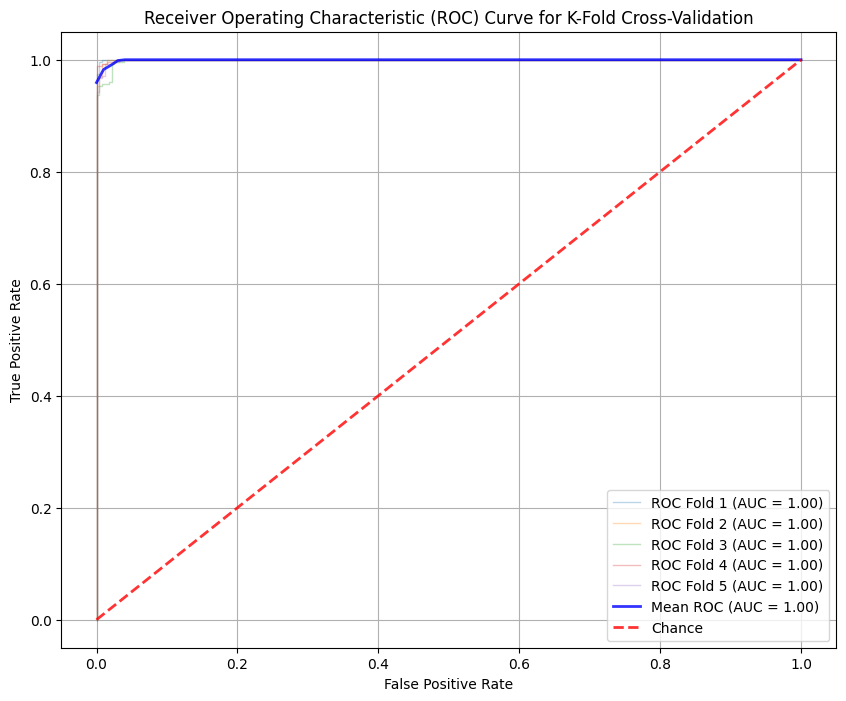

In [3]:
import torch
import torch.nn as nn
import numpy as np
from scipy import signal
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt

SAMPLING_RATE = 256
WINDOW_DURATION = 2
WINDOW_SIZE = SAMPLING_RATE * WINDOW_DURATION
BLINK_THRESHOLD = 150.0

class AttentionClassifierNet(nn.Module):
    def __init__(self):
        super(AttentionClassifierNet, self).__init__()
        # Define separate pathways for each frequency band
        # Each band takes 1 feature (its log-normalized power) and outputs 2 features
        self.delta_pathway = nn.Sequential(
            nn.Linear(1, 2),
            nn.ReLU()
        )
        self.theta_pathway = nn.Sequential(
            nn.Linear(1, 2),
            nn.ReLU()
        )
        self.alpha_pathway = nn.Sequential(
            nn.Linear(1, 2),
            nn.ReLU()
        )
        self.beta_pathway = nn.Sequential(
            nn.Linear(1, 2),
            nn.ReLU()
        )
        self.gamma_pathway = nn.Sequential(
            nn.Linear(1, 2),
            nn.ReLU()
        )

        # Pathway for the remaining features: log_tbr, log_alpha_theta_ratio, log_beta_gamma_ratio, log_signal_std
        # These are 4 features, let's output 4 features
        self.other_features_pathway = nn.Sequential(
            nn.Linear(4, 4),
            nn.ReLU()
        )

        # The total output from all pathways will be (5 bands * 2 features/band) + (1 other pathway * 4 features/pathway) = 10 + 4 = 14 features
        self.combined_layer_1 = nn.Linear(14, 16) # First layer after combining pathways
        self.combined_layer_2 = nn.Linear(16, 8)  # Second layer after combining pathways
        self.output_layer = nn.Linear(8, 1) # Final output layer

        self.activation = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x is expected to be (batch_size, 9)
        # Extract features for each pathway
        # Features order: log_tbr (0), log_theta (1), log_beta (2), log_delta (3), log_alpha (4), log_gamma (5), log_alpha_theta_ratio (6), log_beta_gamma_ratio (7), log_signal_std (8)

        # Reshape to (batch_size, 1) for single feature pathways
        delta_out = self.delta_pathway(x[..., 3].unsqueeze(1))
        theta_out = self.theta_pathway(x[..., 1].unsqueeze(1))
        alpha_out = self.alpha_pathway(x[..., 4].unsqueeze(1))
        beta_out = self.beta_pathway(x[..., 2].unsqueeze(1))
        gamma_out = self.gamma_pathway(x[..., 5].unsqueeze(1))

        # Other features: log_tbr, log_alpha_theta_ratio, log_beta_gamma_ratio, log_signal_std
        other_features_input = x[..., [0, 6, 7, 8]]
        other_out = self.other_features_pathway(other_features_input)

        # Concatenate outputs from all pathways
        combined_features = torch.cat((delta_out, theta_out, alpha_out, beta_out, gamma_out, other_out), dim=1)

        # Pass through combined layers
        x = self.activation(self.combined_layer_1(combined_features))
        x = self.activation(self.combined_layer_2(x))
        x = self.sigmoid(self.output_layer(x))
        return x

def process_eeg_window(raw_signal_data):
    cleaned_signal = np.where(np.abs(raw_signal_data) > BLINK_THRESHOLD, 0.0, raw_signal_data)
    frequencies, power_density = signal.welch(cleaned_signal, fs=SAMPLING_RATE, nperseg=WINDOW_SIZE)

    # Define frequency bands
    delta_indices = np.where((frequencies >= 0.5) & (frequencies <= 4))
    theta_indices = np.where((frequencies >= 4) & (frequencies <= 7))
    alpha_indices = np.where((frequencies >= 8) & (frequencies <= 12))
    beta_indices = np.where((frequencies >= 13) & (frequencies <= 30))
    gamma_indices = np.where((frequencies >= 30) & (frequencies <= 70))

    # Calculate power for each band
    delta_power = np.sum(power_density[delta_indices])
    theta_power = np.sum(power_density[theta_indices])
    alpha_power = np.sum(power_density[alpha_indices])
    beta_power = np.sum(power_density[beta_indices])
    gamma_power = np.sum(power_density[gamma_indices])

    tbr_ratio = theta_power / (beta_power + 1e-6)

    # Calculate new advanced features
    alpha_theta_ratio = alpha_power / (theta_power + 1e-6)
    beta_gamma_ratio = beta_power / (gamma_power + 1e-6)
    signal_std = np.std(cleaned_signal) # Standard deviation as a measure of complexity

    # Log-normalize all powers and ratios
    log_tbr = np.log1p(tbr_ratio)
    log_theta = np.log1p(theta_power)
    log_beta = np.log1p(beta_power)
    log_delta = np.log1p(delta_power)
    log_alpha = np.log1p(alpha_power)
    log_gamma = np.log1p(gamma_power)
    log_alpha_theta_ratio = np.log1p(alpha_theta_ratio)
    log_beta_gamma_ratio = np.log1p(beta_gamma_ratio)
    log_signal_std = np.log1p(signal_std)

    # Return all log-normalized features, including the new ones
    return torch.tensor([
        log_tbr, log_theta, log_beta, log_delta, log_alpha, log_gamma,
        log_alpha_theta_ratio, log_beta_gamma_ratio, log_signal_std
    ], dtype=torch.float32)

def generate_synthetic_eeg_stream(blended_state_strength=0.0): # 0.0 for focused, 1.0 for drift
    t = np.linspace(0, WINDOW_DURATION, WINDOW_SIZE)

    # Introduce variability in base noise
    base_noise_std = np.random.uniform(10, 20) # Vary base noise amplitude
    noise = np.random.normal(0, base_noise_std, WINDOW_SIZE)

    # Add muscle artifact noise (high frequency, short bursts)
    if np.random.rand() < 0.3: # 30% chance of muscle artifact
        muscle_artifact_duration = int(SAMPLING_RATE * np.random.uniform(0.05, 0.2))
        muscle_artifact_start = np.random.randint(0, WINDOW_SIZE - muscle_artifact_duration)
        muscle_artifact_end = muscle_artifact_start + muscle_artifact_duration
        muscle_noise_amp = np.random.uniform(20, 30) # Vary muscle noise amplitude
        muscle_noise = np.random.normal(0, muscle_noise_amp, muscle_artifact_duration)
        noise[muscle_artifact_start:muscle_artifact_end] += muscle_noise

    # Add baseline wander (low frequency fluctuation)
    if np.random.rand() < 0.4: # 40% chance of baseline wander
        baseline_wander_freq = np.random.uniform(0.1, 0.5)
        baseline_wander_amplitude = np.random.uniform(5, 20)
        baseline_wander = baseline_wander_amplitude * np.sin(2 * np.pi * baseline_wander_freq * t)
        noise += baseline_wander

    # Define amplitude and noise ranges for focused and drift states
    # For the interpolate function to work deterministically for training, we'll use mean values or fixed ranges
    # Focused state ranges (min_val, max_val)
    theta_amp_focused_range = (8, 12)
    theta_noise_focused_range = (1, 3)
    beta_amp_focused_range = (30, 40)
    beta_noise_focused_range = (1, 3)
    alpha_amp_focused_range = (20, 30)
    delta_amp_focused_range = (3, 7)
    gamma_amp_focused_range = (3, 7)

    # Drift state ranges (min_val, max_val)
    theta_amp_drift_range = (40, 50)
    theta_noise_drift_range = (4, 6)
    beta_amp_drift_range = (4, 6)
    beta_noise_drift_range = (4, 6)
    alpha_amp_drift_range = (12, 18)
    delta_amp_drift_range = (18, 22)
    gamma_amp_drift_range = (8, 12)

    # Interpolate parameters based on blended_state_strength
    # The interpolate function now takes 4 values (min_focused, max_focused, min_drift, max_drift) and interpolates between a random value from the focused range and a random value from the drift range.
    # This maintains inter-subject variability while enabling smooth transitions.
    def interpolate(min_focused, max_focused, min_drift, max_drift, strength):
        # Get a random value from the focused range
        focused_val = np.random.uniform(min_focused, max_focused)
        # Get a random value from the drift range
        drift_val = np.random.uniform(min_drift, max_drift)
        return (1 - strength) * focused_val + strength * drift_val

    theta_amp = interpolate(*theta_amp_focused_range, *theta_amp_drift_range, blended_state_strength)
    theta_noise_std = interpolate(*theta_noise_focused_range, *theta_noise_drift_range, blended_state_strength)
    beta_amp = interpolate(*beta_amp_focused_range, *beta_amp_drift_range, blended_state_strength)
    beta_noise_std = interpolate(*beta_noise_focused_range, *beta_noise_drift_range, blended_state_strength)
    alpha_amp = interpolate(*alpha_amp_focused_range, *alpha_amp_drift_range, blended_state_strength)
    delta_amp = interpolate(*delta_amp_focused_range, *delta_amp_drift_range, blended_state_strength)
    gamma_amp = interpolate(*gamma_amp_focused_range, *gamma_amp_drift_range, blended_state_strength)

    theta_wave = theta_amp * np.sin(2 * np.pi * 5.5 * t) + np.random.normal(0, theta_noise_std, WINDOW_SIZE)
    beta_wave = beta_amp * np.sin(2 * np.pi * 20 * t) + np.random.normal(0, beta_noise_std, WINDOW_SIZE)
    alpha_wave = alpha_amp * np.sin(2 * np.pi * 10 * t)
    delta_wave = delta_amp * np.sin(2 * np.pi * 2 * t)
    gamma_wave = gamma_amp * np.sin(2 * np.pi * 40 * t)

    simulated_signal = theta_wave + beta_wave + alpha_wave + delta_wave + gamma_wave + noise
    if np.random.rand() > 0.8: # Keep blink simulation
        simulated_signal[120:125] = 220.0

    return simulated_signal

def train_network(model, X_data, y_data):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
    criterion = nn.BCELoss()

    # Convert numpy arrays to PyTorch tensors if they aren't already
    X_data_tensor = torch.tensor(X_data, dtype=torch.float32)
    y_data_tensor = torch.tensor(y_data, dtype=torch.float32).unsqueeze(1)

    model.train()
    for epoch in range(200):
        optimizer.zero_grad()
        outputs = model(X_data_tensor)
        loss = criterion(outputs, y_data_tensor)
        loss.backward()
        optimizer.step()
    model.eval()

# Generate a larger dataset for robust validation
num_total_samples = 2000 # Increased number of samples
X_full, y_full = [], []

for _ in range(num_total_samples // 2):
    # Pure focused state
    X_full.append(process_eeg_window(generate_synthetic_eeg_stream(blended_state_strength=0.0)).numpy())
    y_full.append(0.0)
    # Pure drift state
    X_full.append(process_eeg_window(generate_synthetic_eeg_stream(blended_state_strength=1.0)).numpy())
    y_full.append(1.0)

    # Intermediate blended states
    # Generate a significant portion of blended states to train and test generalization
    if np.random.rand() < 0.7: # Increased probability of blended states
        intermediate_strength = np.random.uniform(0.1, 0.9) # Random strength between focused and drift
        X_full.append(process_eeg_window(generate_synthetic_eeg_stream(blended_state_strength=intermediate_strength)).numpy())
        y_full.append(intermediate_strength)

X_full = np.array(X_full)
y_full = np.array(y_full)

print(f"Generated a dataset of {len(X_full)} samples.")

# K-Fold Cross-Validation Setup
num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

# Lists to store metrics for each fold
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
roc_auc_scores = []
all_fpr = []
all_tpr = []

print(f"\n--- Starting {num_folds}-Fold Cross-Validation ---")

# Iterate through each fold
for fold, (train_index, val_index) in enumerate(kf.split(X_full)):
    print(f"\nFold {fold + 1}/{num_folds}")

    # Split data for the current fold
    X_train, X_val = X_full[train_index], X_full[val_index]
    y_train, y_val = y_full[train_index], y_full[val_index]

    # Initialize a new model for each fold to ensure independent training
    model = AttentionClassifierNet()

    # Train the model on the training data for this fold
    train_network(model, X_train, y_train)

    # Evaluate the model on the validation data
    model.eval()
    with torch.no_grad():
        val_outputs = model(torch.tensor(X_val, dtype=torch.float32)).squeeze(1)
        # For binary classification metrics, we need to convert probabilities to hard predictions
        # using a threshold. Let's use 0.5 as the threshold for 'drift' (1) vs 'focused' (0).
        val_preds = (val_outputs >= 0.5).int().numpy()
        y_val_binary = (y_val >= 0.5).astype(int) # Convert true labels to binary for metrics

    # Calculate and store metrics
    accuracy_scores.append(accuracy_score(y_val_binary, val_preds))
    precision_scores.append(precision_score(y_val_binary, val_preds, zero_division=0)) # Handle cases with no positive predictions
    recall_scores.append(recall_score(y_val_binary, val_preds, zero_division=0))
    f1_scores.append(f1_score(y_val_binary, val_preds, zero_division=0))

    # Calculate ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_val_binary, val_outputs.numpy())
    roc_auc = auc(fpr, tpr)
    roc_auc_scores.append(roc_auc)
    all_fpr.append(fpr)
    all_tpr.append(tpr)

    print(f"Accuracy: {accuracy_scores[-1]:.4f}")
    print(f"Precision: {precision_scores[-1]:.4f}")
    print(f"Recall: {recall_scores[-1]:.4f}")
    print(f"F1-Score: {f1_scores[-1]:.4f}")
    print(f"ROC AUC: {roc_auc_scores[-1]:.4f}")

# Calculate and print average metrics
print("\n--- Average Cross-Validation Metrics ---")
print(f"Average Accuracy: {np.mean(accuracy_scores):.4f} (+/- {np.std(accuracy_scores):.4f})")
print(f"Average Precision: {np.mean(precision_scores):.4f} (+/- {np.std(precision_scores):.4f})")
print(f"Average Recall: {np.mean(recall_scores):.4f} (+/- {np.std(recall_scores):.4f})")
print(f"Average F1-Score: {np.mean(f1_scores):.4f} (+/- {np.std(f1_scores):.4f})")
print(f"Average ROC AUC: {np.mean(roc_auc_scores):.4f} (+/- {np.std(roc_auc_scores):.4f})")

# Plotting all ROC curves and the average ROC curve
plt.figure(figsize=(10, 8))
for i in range(num_folds):
    plt.plot(all_fpr[i], all_tpr[i], lw=1, alpha=0.3, label=f'ROC Fold {i+1} (AUC = {roc_auc_scores[i]:.2f})')

# Plot average ROC curve (simple average for visualization)
# Note: A more robust average ROC would use interpolation and then averaging
mean_fpr = np.linspace(0, 1, 100)
mean_tpr = []
for i in range(num_folds):
    mean_tpr.append(np.interp(mean_fpr, all_fpr[i], all_tpr[i]))

mean_tpr = np.mean(mean_tpr, axis=0)
mean_auc = np.mean(roc_auc_scores)
plt.plot(mean_fpr, mean_tpr, color='b', label=f'Mean ROC (AUC = {mean_auc:.2f})', lw=2, alpha=.8)

plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for K-Fold Cross-Validation')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()